# 05 - Analiza bledow

Dwie czesci: regresja (residua) i klasyfikacja (pomylki). Celem jest *zrozumiec*,
gdzie i czemu modele sie myla - to czesto ciekawsze niz sama metryka.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

reg = pd.read_parquet('../data/reg_predictions.parquet')
clf = pd.read_parquet('../data/clf_predictions.parquet')
reg['residual'] = reg['actual'] - reg['pred_hgb']
print('reg:', reg.shape, '| clf:', clf.shape)

reg: (4542, 18) | clf: (479, 13)


## Regresja: rozklad residuow

Residuum > 0 -> model przewidzial za szybko (rzeczywisty czas wyzszy).

MAE: 11.928 | bias: 9.374


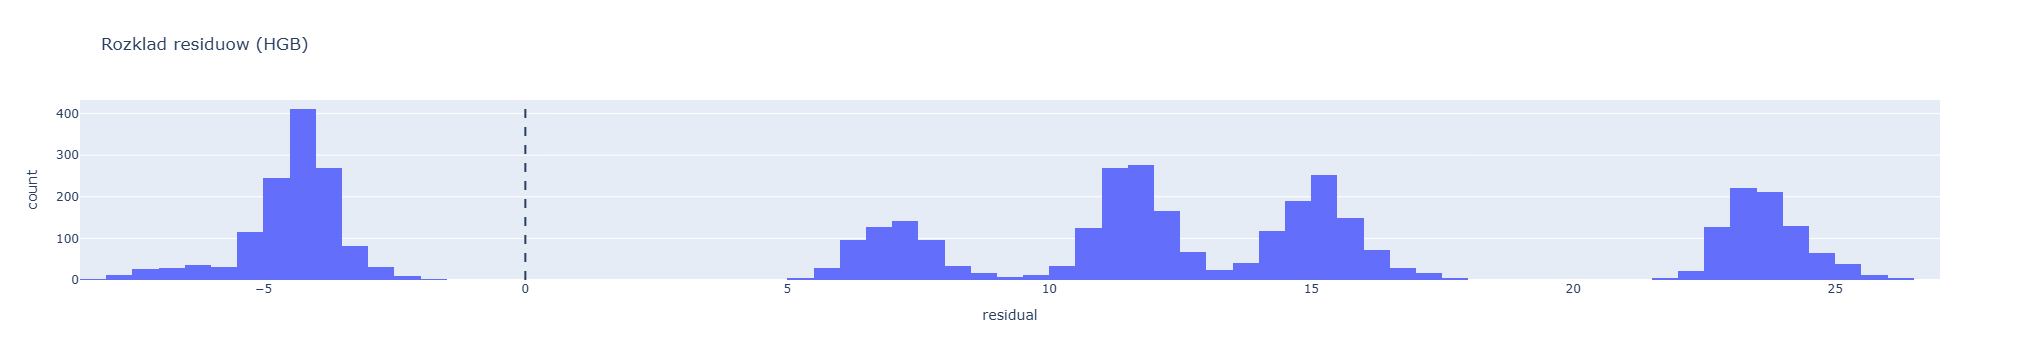

In [2]:
print('MAE:', reg['residual'].abs().mean().round(3),
      '| bias:', reg['residual'].mean().round(3))
fig = px.histogram(reg, x='residual', nbins=80, title='Rozklad residuow (HGB)')
fig.add_vline(x=0, line_dash='dash')
fig.show()

### Residua vs cechy - czy zostal jakis wzorzec?

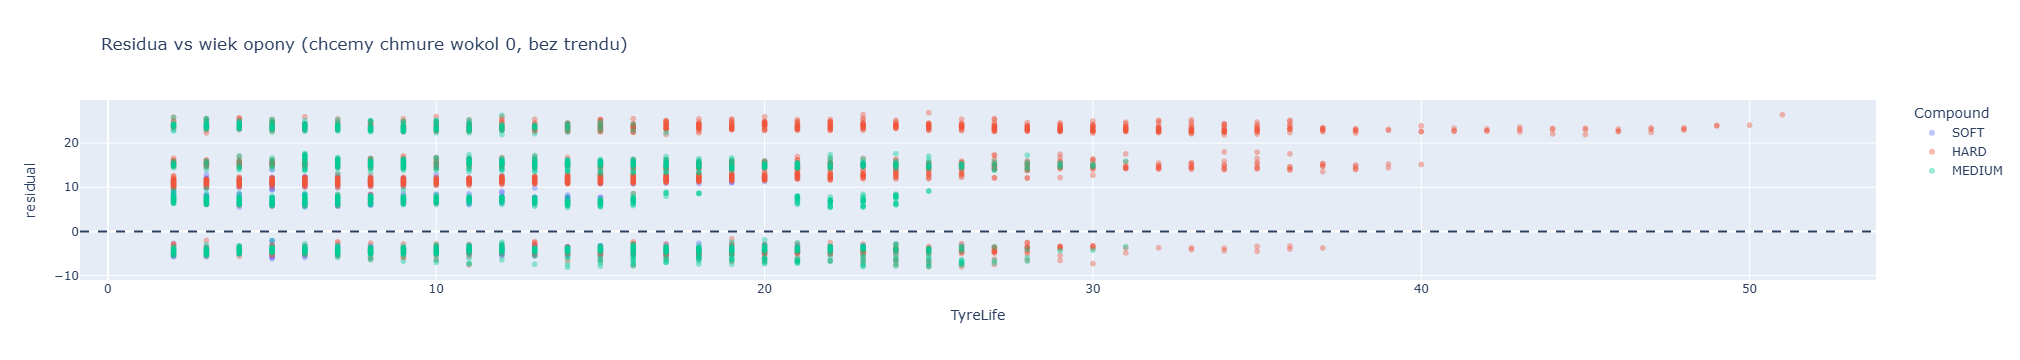

In [3]:
fig = px.scatter(reg, x='TyreLife', y='residual', color='Compound', opacity=0.4,
                 title='Residua vs wiek opony (chcemy chmure wokol 0, bez trendu)')
fig.add_hline(y=0, line_dash='dash')
fig.show()

### Blad per mieszanka

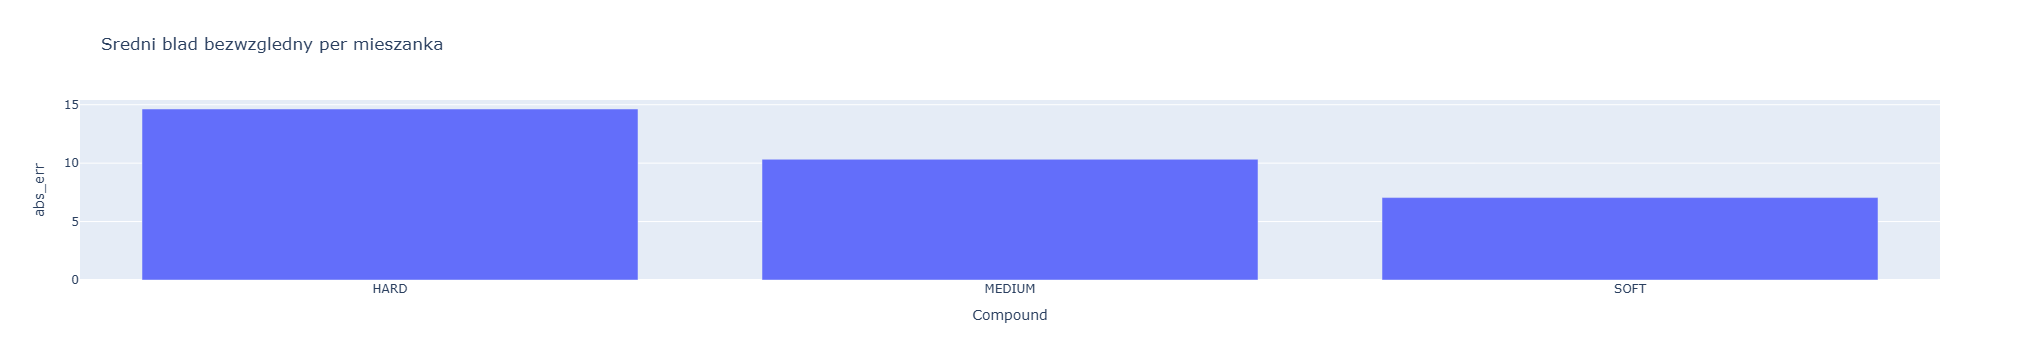

In [4]:
by_comp = reg.assign(abs_err=reg['residual'].abs()).groupby('Compound')['abs_err'].mean().reset_index()
fig = px.bar(by_comp, x='Compound', y='abs_err', title='Sredni blad bezwzgledny per mieszanka')
fig.show()

### Najgorzej przewidziane okrazenia

In [5]:
worst = reg.reindex(reg['residual'].abs().sort_values(ascending=False).index).head(15)
worst[['Round', 'Compound', 'TyreLife', 'LapNumber', 'actual', 'pred_hgb', 'residual']].round(2)

,Round,Compound,TyreLife,LapNumber,actual,pred_hgb,residual
3434,17,HARD,25.0,37.0,110.67,83.81,26.86
3244,17,HARD,23.0,22.0,112.59,86.15,26.44
3313,17,HARD,51.0,48.0,111.78,85.38,26.40
3094,17,MEDIUM,12.0,11.0,112.48,86.21,26.27
3420,17,HARD,10.0,22.0,110.67,84.67,26.00
2847,17,HARD,12.0,24.0,110.60,84.63,25.97
3283,17,HARD,20.0,17.0,112.19,86.23,25.96
3270,17,HARD,6.0,3.0,112.03,86.09,25.94
3314,17,HARD,2.0,2.0,111.64,85.76,25.88
3182,17,MEDIUM,2.0,2.0,112.03,86.23,25.80


## Klasyfikacja: gdzie model sie myli

Najciekawsze sa bledy 'blisko granicy' - kierowcy z P4-P5, ktorych model typowal
na podium, i odwrotnie. Patrzymy tez na kalibracje prawdopodobienstwa.

In [6]:
clf['err_type'] = np.select(
    [(clf.podium == 1) & (clf.pred_logit == 1),
     (clf.podium == 0) & (clf.pred_logit == 0),
     (clf.podium == 0) & (clf.pred_logit == 1),
     (clf.podium == 1) & (clf.pred_logit == 0)],
    ['TP', 'TN', 'FP (typowal podium, nie bylo)', 'FN (przegapil podium)'],
    default='unknown')
clf['err_type'].value_counts()

err_type
TN                               327
FP (typowal podium, nie bylo)     80
TP                                67
FN (przegapil podium)              5
Name: count, dtype: int64

In [7]:
miss = clf[clf.podium != clf.pred_logit].sort_values('proba_logit', ascending=False)
miss[['Round', 'Driver', 'Team', 'GridPosition', 'Position',
      'proba_logit', 'podium', 'err_type']].round(3).head(20)

,Round,Driver,Team,GridPosition,Position,proba_logit,podium,err_type
3,1,LEC,Ferrari,2.0,4.0,0.916,0,"FP (typowal podium, nie bylo)"
58,3,VER,Red Bull Racing,1.0,19.0,0.909,0,"FP (typowal podium, nie bylo)"
404,21,NOR,McLaren,1.0,6.0,0.900,0,"FP (typowal podium, nie bylo)"
336,17,SAI,Ferrari,3.0,18.0,0.893,0,"FP (typowal podium, nie bylo)"
362,19,NOR,McLaren,1.0,4.0,0.882,0,"FP (typowal podium, nie bylo)"
203,11,VER,Red Bull Racing,1.0,5.0,0.881,0,"FP (typowal podium, nie bylo)"
384,20,VER,Red Bull Racing,2.0,6.0,0.876,0,"FP (typowal podium, nie bylo)"
468,24,PIA,McLaren,2.0,10.0,0.871,0,"FP (typowal podium, nie bylo)"
265,14,PER,Red Bull Racing,2.0,7.0,0.867,0,"FP (typowal podium, nie bylo)"
422,22,LEC,Ferrari,4.0,4.0,0.866,0,"FP (typowal podium, nie bylo)"


### Kalibracja - czy 'prawdopodobienstwa' cos znacza

In [8]:
clf['bin'] = pd.cut(clf['proba_logit'], bins=np.linspace(0, 1, 11))
cal = clf.groupby('bin', observed=True).agg(
    mean_pred=('proba_logit', 'mean'),
    frac_pos=('podium', 'mean'),
    n=('podium', 'size')).dropna().reset_index()
fig = px.scatter(cal, x='mean_pred', y='frac_pos', size='n',
                 title='Krzywa kalibracji (logit)',
                 labels={'mean_pred': 'srednie P(podium)', 'frac_pos': 'realny udzial podiow'})
fig.add_shape(type='line', x0=0, y0=0, x1=1, y1=1, line=dict(dash='dash', color='red'))
fig.show()

## Wnioski (do uzupelnienia po odpaleniu)

- Regresja: gdzie najwiekszy blad? (typowo restarty/traffic, ktore przetrwaly filtr;
  stare opony - duzy rozrzut)
- Klasyfikacja: ktore wyscigi 'zaskoczyly' model (deszcz, chaos, SC) - to naturalne
  granice przewidywalnosci podium z samej pozycji startowej.